In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("flights.csv")

# Basic info
print(df.head())
print(df.info())
print(df.describe())

   index        airline date_of_journey     Source destination  \
0      1  AirAsia India      2024-02-25   Guwahati      Indore   
1      2         TruJet      2021-03-01     Nagpur        Pune   
2      3       Star Air      2024-04-11  Ahmedabad    Varanasi   
3      4       SpiceJet      2019-03-13      Patna      Indore   
4      5       SpiceJet      2023-06-22     Raipur      Mumbai   

                 route dep_time Arrival_time   Duration Total_stops  \
0  GUW-NAG-MUM-RAI-IND    01:39        14:15   3h 15min     3 stops   
1              NAG-PUN    06:48        03:21    1h 0min    non-stop   
2      AHM-PUN-BAN-VAR    08:54        15:50  14h 30min     2 stops   
3  PAT-LUC-GOA-BHU-IND    18:09        08:23   7h 15min     3 stops   
4          RAI-GOA-MUM    15:05        05:52  15h 30min      1 stop   

               Additional_info  Price  
0               Red-eye flight  14170  
1               1 Long layover  10295  
2  In-flight meal not included   9165  
3               

In [9]:
df = pd.read_csv("flights.csv")

df.columns = df.columns.str.lower().str.strip()

print(df.columns)

Index(['index', 'airline', 'date_of_journey', 'source', 'destination', 'route',
       'dep_time', 'arrival_time', 'duration', 'total_stops',
       'additional_info', 'price'],
      dtype='object')


In [10]:
print(df.columns)

Index(['index', 'airline', 'date_of_journey', 'source', 'destination', 'route',
       'dep_time', 'arrival_time', 'duration', 'total_stops',
       'additional_info', 'price'],
      dtype='object')


In [11]:
df['date_of_journey'] = pd.to_datetime(df['date_of_journey'], errors='coerce')

df['journey_day'] = df['date_of_journey'].dt.day
df['journey_month'] = df['date_of_journey'].dt.month
df['journey_month_name'] = df['date_of_journey'].dt.month_name()
df['journey_weekday'] = df['date_of_journey'].dt.day_name()

In [12]:
df.drop(columns=['date_of_journey'], inplace=True)

In [13]:
print(df['duration'].head())

0     3h 15min
1      1h 0min
2    14h 30min
3     7h 15min
4    15h 30min
Name: duration, dtype: object


In [15]:
import re

def convert_duration(x):
    hours = 0
    minutes = 0
    
    # Extract hours
    h = re.search(r'(\d+)h', x)
    if h:
        hours = int(h.group(1))
    
    # Extract minutes
    m = re.search(r'(\d+)m', x)
    if m:
        minutes = int(m.group(1))
    
    return hours * 60 + minutes

df['duration_mins'] = df['duration'].apply(convert_duration)

In [16]:
df['duration_category'] = pd.cut(
    df['duration_mins'],
    bins=[0, 120, 300, 600, 2000],
    labels=['Short', 'Medium', 'Long', 'Very Long']
)

In [17]:
print(df[['duration', 'duration_mins']].head())

    duration  duration_mins
0   3h 15min            195
1    1h 0min             60
2  14h 30min            870
3   7h 15min            435
4  15h 30min            930


In [19]:
print(df['total_stops'].unique())

['3 stops' 'non-stop' '2 stops' '1 stop']


In [20]:
df['total_stops'] = df['total_stops'].replace({
    'non-stop': 0,
    '1 stop': 1,
    '2 stops': 2,
    '3 stops': 3,
    '4 stops': 4
})

df['total_stops'] = pd.to_numeric(df['total_stops'], errors='coerce')

C:\Users\User\AppData\Local\Temp\ipykernel_12344\1683816348.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['total_stops'] = df['total_stops'].replace({


In [21]:
df['total_stops'] = (
    df['total_stops']
    .replace({
        'non-stop': 0,
        '1 stop': 1,
        '2 stops': 2,
        '3 stops': 3,
        '4 stops': 4
    })
    .astype(int)
)

In [22]:
print(df['total_stops'].isna().sum())

0


In [23]:
df['total_stops'] = df['total_stops'].fillna(0)

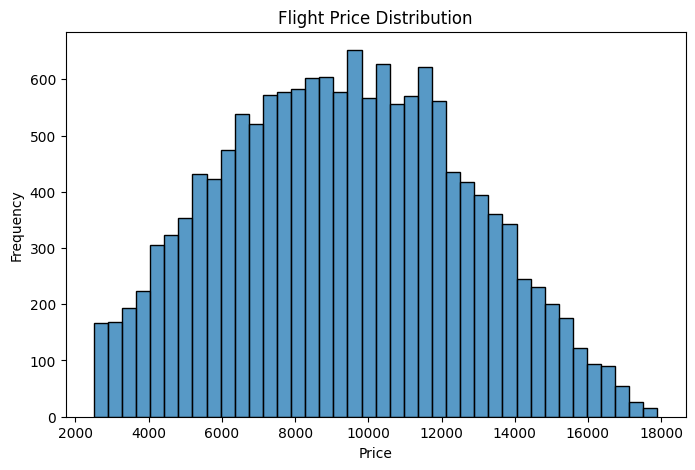

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=40)
plt.title("Flight Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

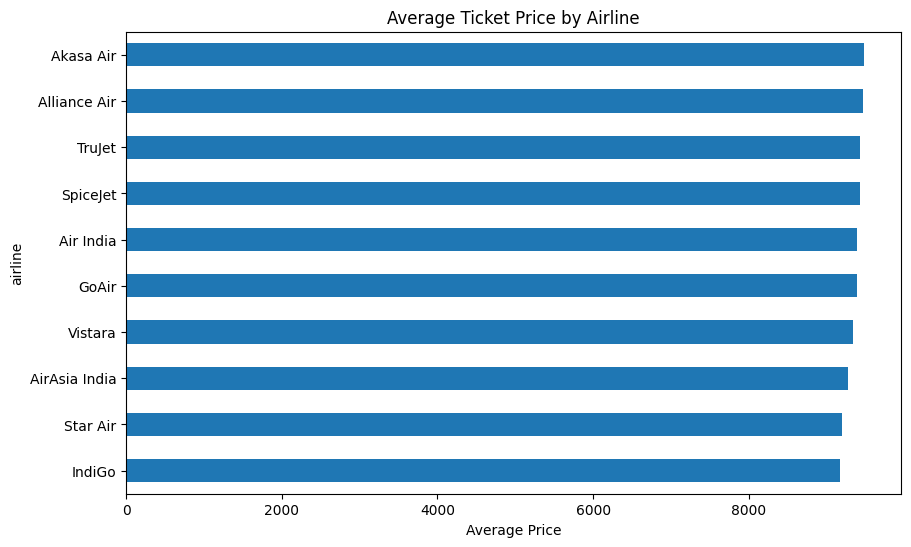

In [25]:
plt.figure(figsize=(10,6))
df.groupby('airline')['price'].mean().sort_values().plot(kind='barh')
plt.title("Average Ticket Price by Airline")
plt.xlabel("Average Price")
plt.show()

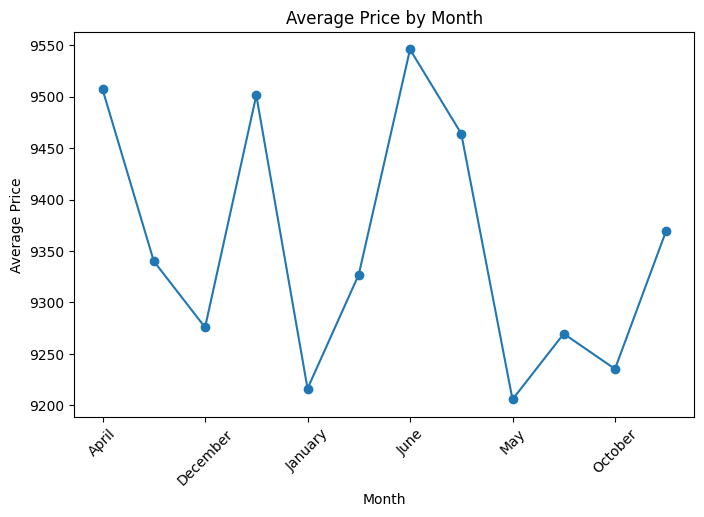

In [26]:
plt.figure(figsize=(8,5))
df.groupby('journey_month_name')['price'].mean().plot(kind='line', marker='o')
plt.title("Average Price by Month")
plt.xlabel("Month")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()

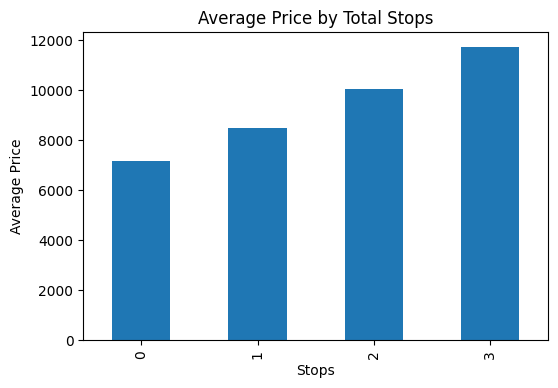

In [27]:
plt.figure(figsize=(6,4))
df.groupby('total_stops')['price'].mean().plot(kind='bar')
plt.title("Average Price by Total Stops")
plt.xlabel("Stops")
plt.ylabel("Average Price")
plt.show()

In [28]:
df['price_per_min'] = df['price'] / df['duration_mins']

In [29]:
df.drop(columns=['index'], inplace=True)

In [30]:
df.drop(columns=['route'], inplace=True)

In [31]:
print(df.isna().sum())

df = df.dropna()

airline               0
source                0
destination           0
dep_time              0
arrival_time          0
duration              0
total_stops           0
additional_info       0
price                 0
journey_day           0
journey_month         0
journey_month_name    0
journey_weekday       0
duration_mins         0
duration_category     0
price_per_min         0
dtype: int64


In [32]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [33]:
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

In [35]:
from sklearn.model_selection import train_test_split

In [36]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [37]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 69.86982666666667
RMSE: 123.97670967779929
R2 Score: 0.9985899074307504


In [39]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10)

price_per_min                  0.593592
duration_mins                  0.268288
total_stops                    0.120291
duration_category_Very Long    0.004279
duration_category_Long         0.003779
duration_category_Medium       0.001755
duration_1h 0min               0.001354
duration_1h 30min              0.000631
duration_1h 15min              0.000466
journey_day                    0.000416
dtype: float64

In [43]:
import streamlit as st
import pandas as pd
import joblib

st.title("Flight Price Prediction Dashboard")

model = joblib.load("flight_model.pkl")

st.write("Enter flight details:")

# Example input
st.number_input("Duration (minutes)")

2026-02-22 15:44:31.470 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-22 15:44:31.491 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-22 15:44:31.536 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-22 15:44:33.541 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-22 15:44:33.574 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-22 15:44:33.577 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-22 15:44:33.583 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-22 15:44:33.594 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

0.0

In [42]:
import joblib

joblib.dump(model, "flight_model.pkl")

['flight_model.pkl']

In [44]:
st.title("Flight Price Prediction Dashboard")

2026-02-22 15:44:56.857 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-22 15:44:56.861 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-22 15:44:56.863 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [45]:
import joblib
joblib.dump(model, "flight_model.pkl")

['flight_model.pkl']

In [46]:
df['predicted_price'] = model.predict(X)
df.to_csv("flight_final_dataset.csv", index=False)